In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
from scipy.special import comb
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import random
import string
import statsmodels.api as sm
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

from joblib import Parallel, delayed
from tqdm import tqdm
from collections import Counter

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

### Read in stories and recalls.

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [3]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           "" for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

print(story_processed_all[0])

print(recall_processed_all[0][0])   # clear clause of each participant.

[' Yeah, I was in the boy scouts at the time. ', ' And we was doing the 50-yard dash, ', ' racing, ', ' but we was at the pier, marked off, ', ' and so we was doing the 50-yard dash. ', ' There was about 8 or 9 of us, you know, going down, coming back. ', ' And, going down the third time, I caught cramps', ' and I started yelling "Help!", ', " but the fellows didn't believe me, you know. ", ' They thought I was just trying to catch up, because I was going on or slowing down. ', ' So all of them kept going. ', ' They leave me. ', ' And so I started going down. ', ' Scoutmaster was up there. ', ' He was watching me. ', " But he didn't pay me no attention either. ", ' And for no reason at all there was another guy, who had just walked up that minute...', ' He just jumped over ', ' and grabbed me.']
[' Yeh, ', ' so I was in the boy scouts ', ' and we was doing the 50 yard dash. ', ' We was doing the 50 yard dash ', ' and two or three times in ', ' and I got the cramps. ', ' I started yelli

In [4]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

In [5]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

print(additional_recall_processed[0][10])

['4 guys went to the same high school together,', "but didn't become close friends until they all went to another school together.", 'The main one lived on a farm', 'and the other 3 lived in the city.', 'They all used to go hunting on his farm together,', "but he didn't really care for hunting.", 'They all decided to go on a bear hunting trip.', 'They travelled for a long time', 'until they got to a cabin they had rented.', 'They stayed there for 3 or 4 days', 'before realising none of them wanted to go hunting.', 'They needed to take a bear home', 'otherwise the other people would give them a bad time.', 'They played a card game to decide who would go and get a bear,', 'and the other 3 would skin the bear and pack it.', 'The main man got the highest card', 'so went to get a bear.', 'He found one', 'and went to shoot', "but realised he hadn't loaded the gun.", 'He ran whilst the bear chased him back to the cabin.', 'He shouted to be let into the cabin', 'and turned left once he got in,

In [6]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
# print(len(story_processed_all))

recall_processed_all = recall_processed_all + additional_recall_processed
print(len(recall_processed_all[0]))

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses)

100
clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [7]:
# get data for clauses in the recalls.
recall_clauses = [[len(recall_processed_all[i][participant]) for participant in np.arange(len(recall_processed_all[i]))] 
                        for i in np.arange(len(recall_processed_all))]
recall_clauses = [[item for item in recall_clauses[i] if item !=0 ] 
                        for i in np.arange(len(recall_clauses))]   # remove missing data in recall.

mean_recall_clauses = [round(np.mean(list_sub), 2) for list_sub in recall_clauses]
print(mean_recall_clauses)

[9.34, 9.07, 9.83, 15.07, 14.04, 16.97, 18.14, 19.29, 24.13, 25.29, 29.74, 21.05]


### get the scoring curve by humans

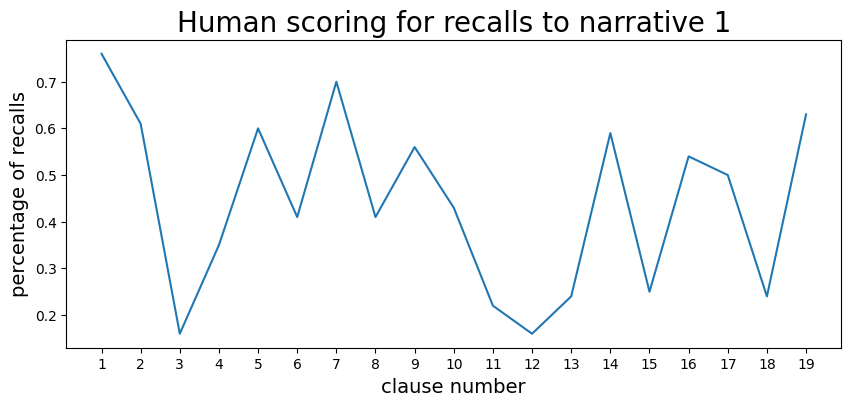

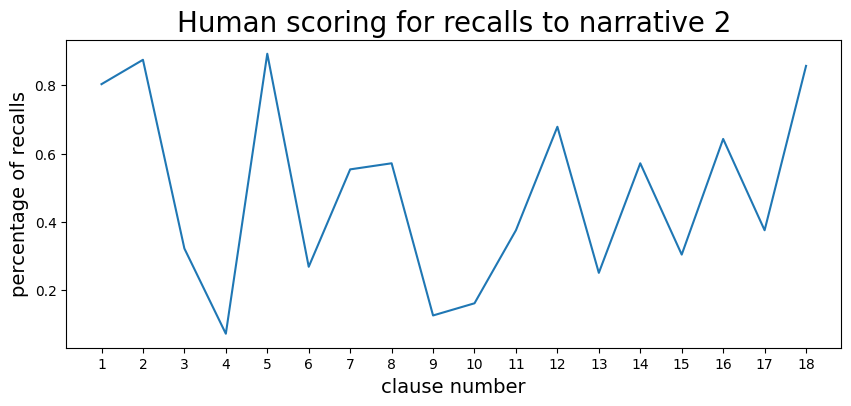

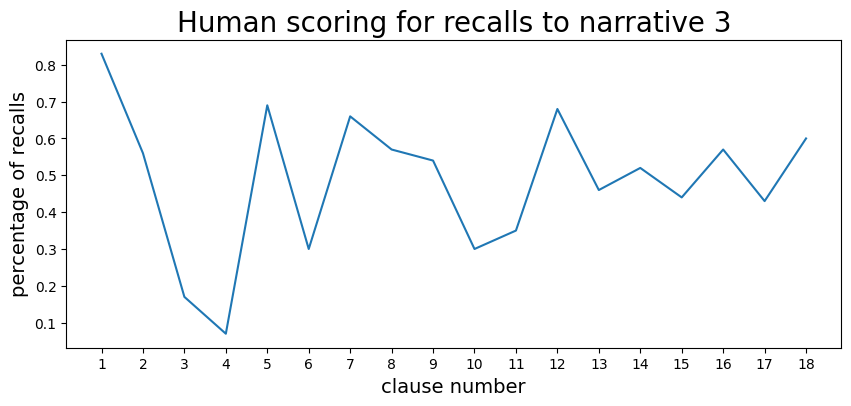

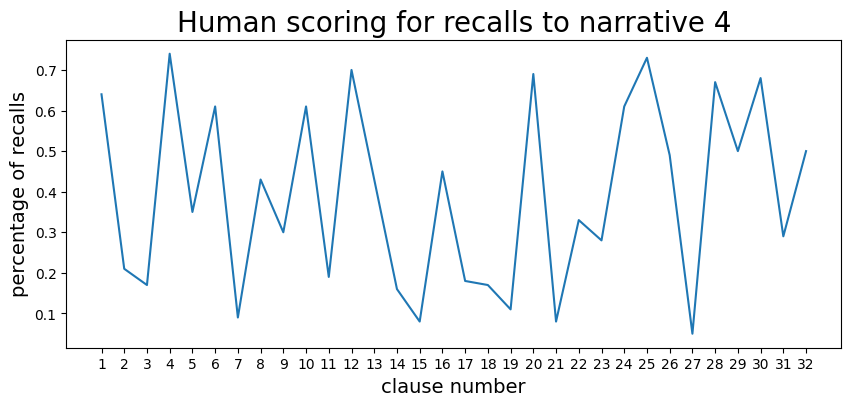

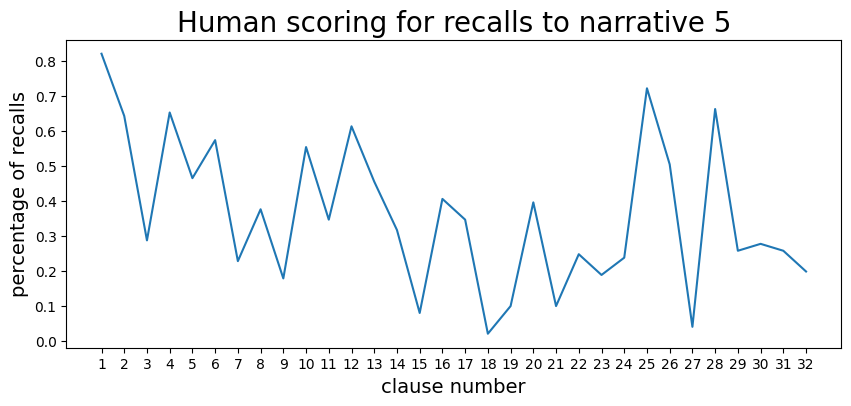

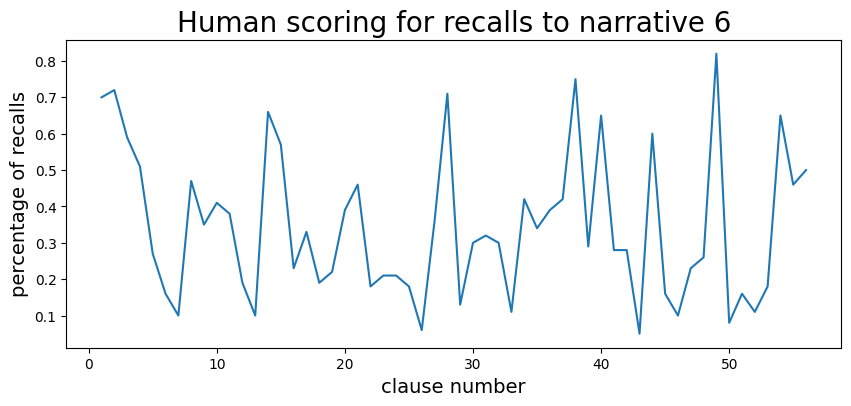

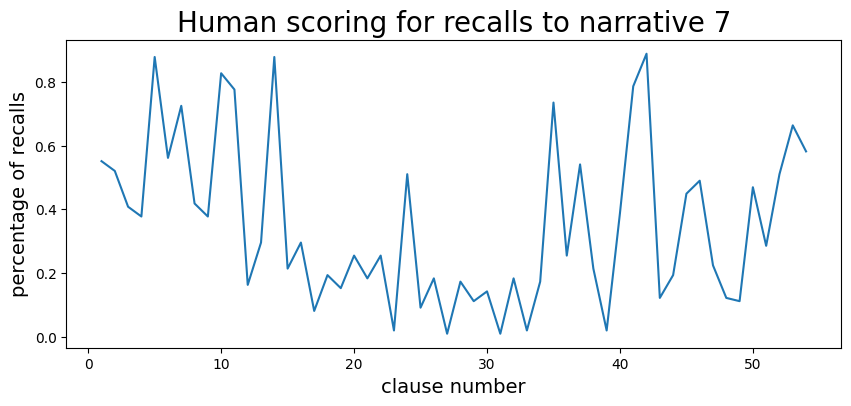

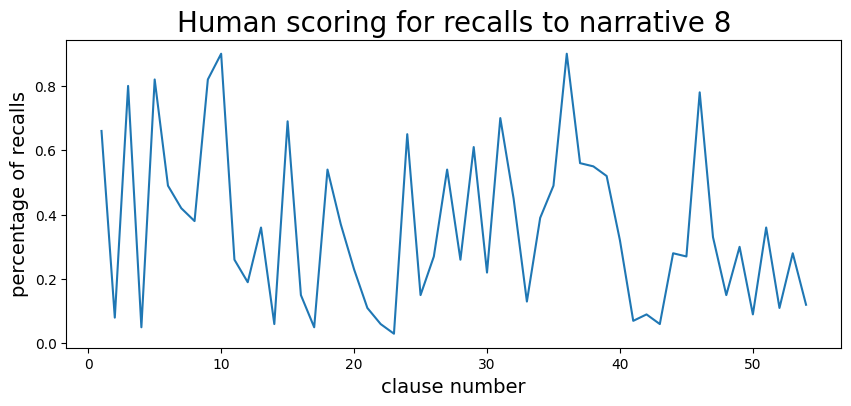

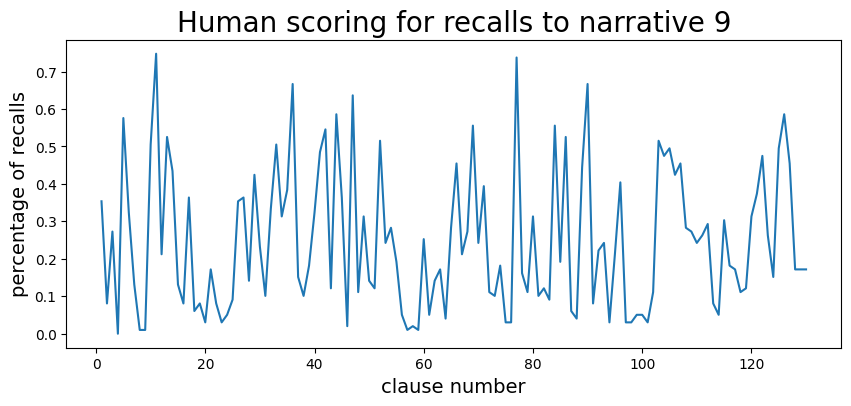

In [8]:
# print(story_all[0].keys())
# story_all += story_additional
percentage_scoring_human = []
for j in np.arange(9):
    scoring_data_narrative1 = story_all[j]['recall scores']
    score_narrative1 = scoring_data_narrative1.values.tolist()
    # print(scoring_data_narrative1.values.tolist())
    flattened_score_narrative1 = [num for sublist in score_narrative1 for num in sublist]
    counts_narrative1 = Counter(flattened_score_narrative1)
    

    x = np.arange(1, clauses[j]+1)
    percentage_score_narrative1 = [counts_narrative1[i]/len(recall_processed_all[j]) for i in x]
    percentage_scoring_human.append(percentage_score_narrative1)

    ## plot the human scoring
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    plt.plot(x, percentage_score_narrative1)
    if j < 5:
        plt.xticks(x) 
    
    plt.title(f"Human scoring for recalls to narrative {j+1}", fontsize=20)
    plt.ylabel("percentage of recalls", fontsize=14)
    plt.xlabel("clause number", fontsize=14)
    plt.show()

### embed the stories and recalls

In [9]:
# embed for the first story.
model = SentenceTransformer('all-MiniLM-L6-v2')
story_emb_all = [model.encode(story) for story in story_processed_all]

recall_emb_all = [[model.encode(participant) for participant in story if len(participant) > 1]
                    for story in recall_processed_all]


In [10]:
## get the scoring on recalls by different threshold.
def convert_degree_threshold(degree):
    th = 1 - math.cos(math.radians(degree))
    return th

angles = list(range(10, 90, 5))   # 10, 15, 20, ..., 85

percentage_embedding_score_narrative = [[] for i in np.arange(9)]
for j in np.arange(9):
    print(f"calculating narrative {j+1}")
    for angle in angles:
        distance_threshold = convert_degree_threshold(angle)

        x = np.arange(1, clauses[j]+1)
        scoring_count = [0 for i in x]
        
        for index, narrative_clause in enumerate(story_emb_all[j]):
            for recall_participant in recall_emb_all[j]:
                for recalled_embedding in recall_participant:
                    if cosine(narrative_clause, recalled_embedding) < distance_threshold:
                        scoring_count[index] += 1
                        break

        percentage_embedding_score_narrative[j].append([item/len(recall_emb_all[0]) for item in scoring_count])
        print(f"  finished angle {angle}°")

calculating narrative 1
  finished angle 10°
  finished angle 15°
  finished angle 20°
  finished angle 25°
  finished angle 30°
  finished angle 35°
  finished angle 40°
  finished angle 45°
  finished angle 50°
  finished angle 55°
  finished angle 60°
  finished angle 65°
  finished angle 70°
  finished angle 75°
  finished angle 80°
  finished angle 85°
calculating narrative 2
  finished angle 10°
  finished angle 15°
  finished angle 20°
  finished angle 25°
  finished angle 30°
  finished angle 35°
  finished angle 40°
  finished angle 45°
  finished angle 50°
  finished angle 55°
  finished angle 60°
  finished angle 65°
  finished angle 70°
  finished angle 75°
  finished angle 80°
  finished angle 85°
calculating narrative 3
  finished angle 10°
  finished angle 15°
  finished angle 20°
  finished angle 25°
  finished angle 30°
  finished angle 35°
  finished angle 40°
  finished angle 45°
  finished angle 50°
  finished angle 55°
  finished angle 60°
  finished angle 65°
  fi

In [11]:
## calculate the correlation with the human scoring.
correlation_scoring = [[] for i in np.arange(9)]
for i in np.arange(9):
    for list_scoring in percentage_embedding_score_narrative[i]:
        correlation = np.corrcoef(percentage_scoring_human[i], list_scoring)
        correlation_scoring[i].append(correlation[0, 1])

print(correlation_scoring[0])

[0.17026135997931888, 0.24536095968226052, 0.4677407597580425, 0.6000177815249389, 0.6477709652113225, 0.6666836137708624, 0.704995067377818, 0.7308271109313731, 0.7266732457966276, 0.7383443211739905, 0.7184214208960741, 0.6498999359138208, 0.4241271017868527, 0.36739212369936386, 0.26963796165119225, nan]


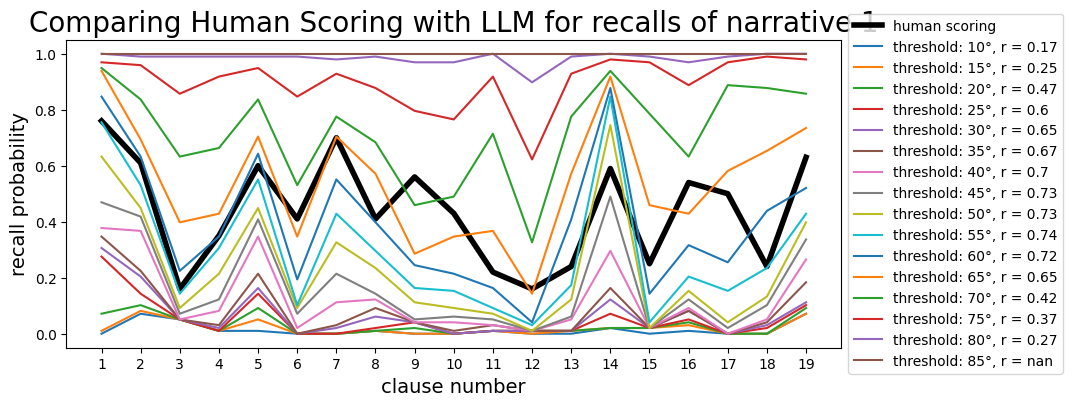

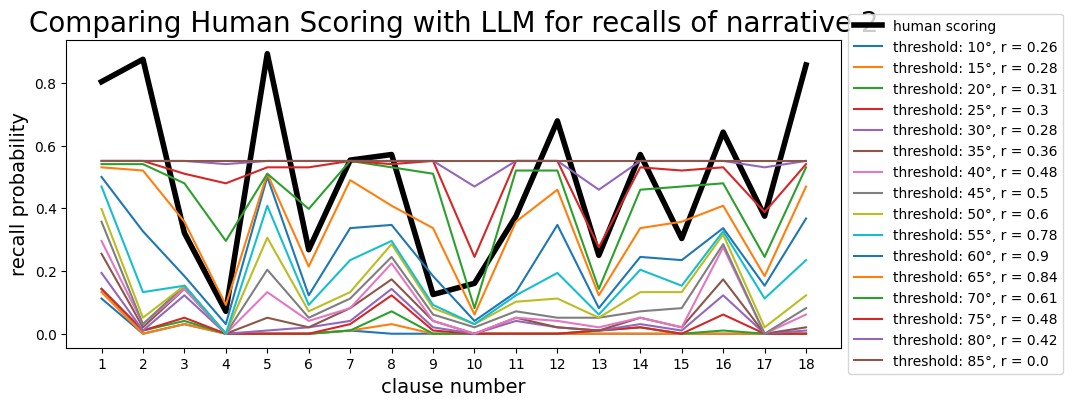

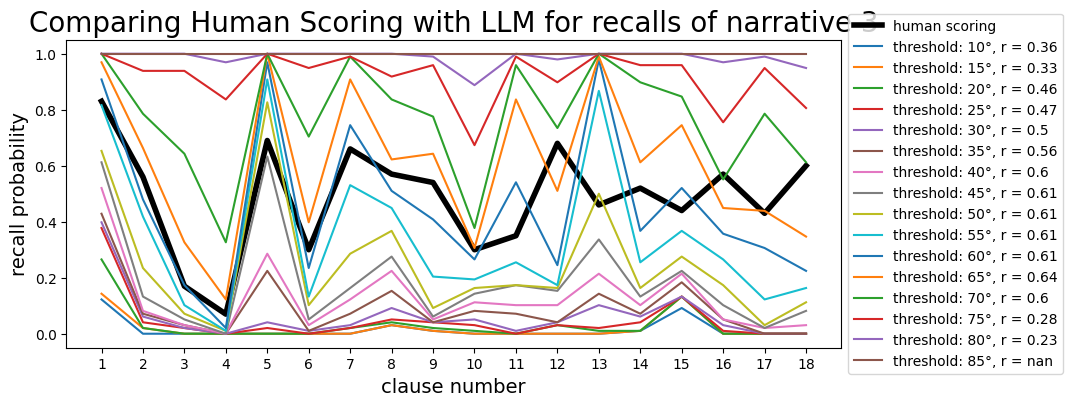

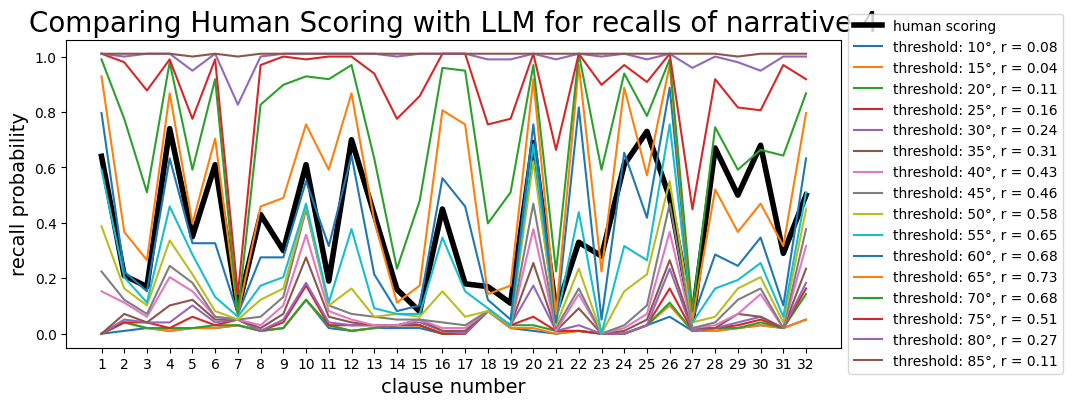

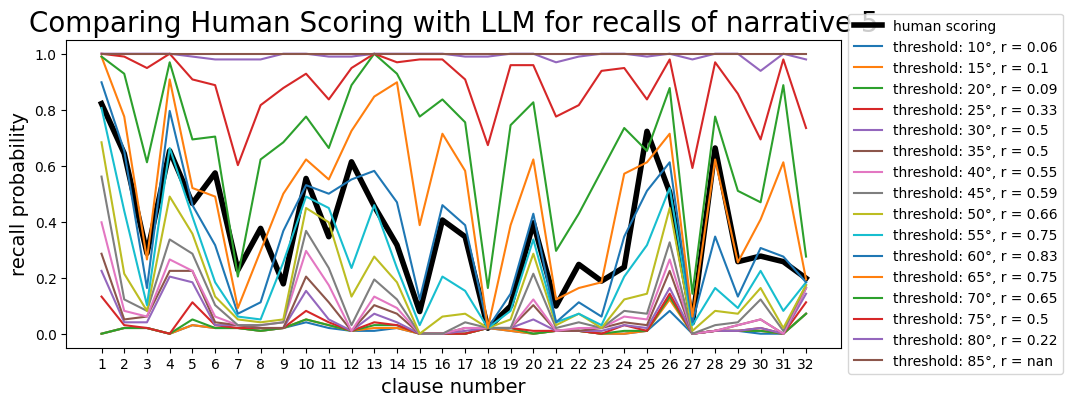

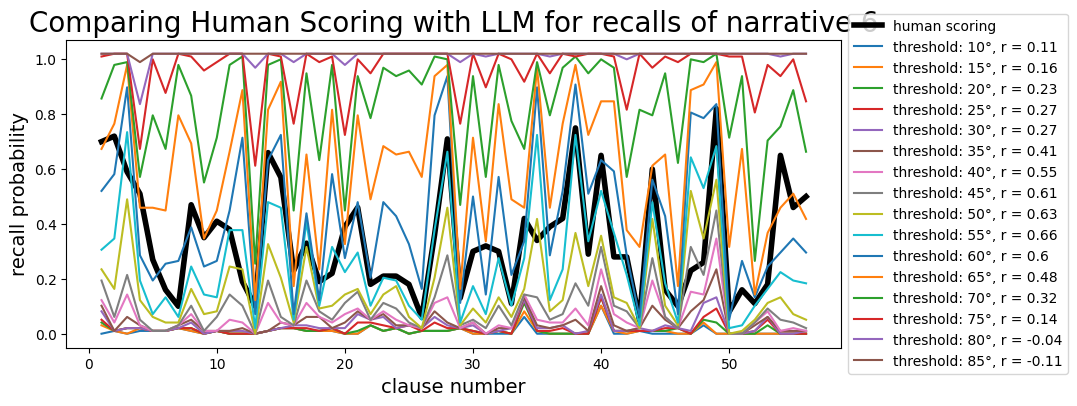

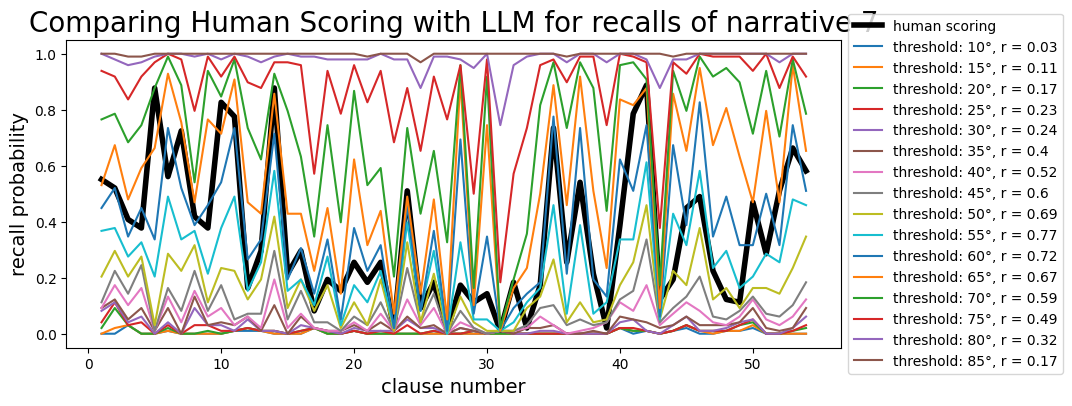

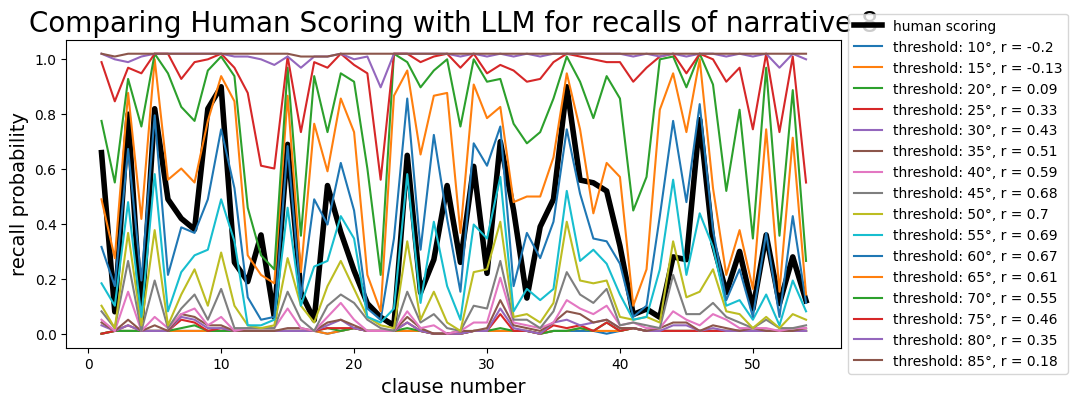

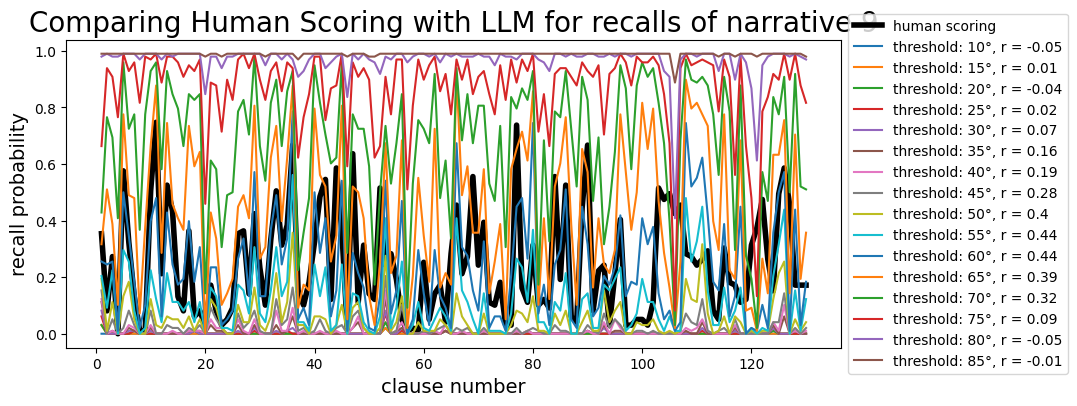

In [16]:
#plot against the human scoring.
for i in np.arange(9):
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    
    x = np.arange(1, clauses[i]+1)
    plt.plot(x, percentage_scoring_human[i], color="black", label="human scoring", linewidth=4)
    if clauses[i] <= 32:
        plt.xticks(x)
    
    for index, list_scoring in enumerate(percentage_embedding_score_narrative[i]):
        plt.plot(x, list_scoring, label=f"threshold: {angles[index]}°, r = {round(correlation_scoring[i][index], 2)}")
    
    plt.title(f"Comparing Human Scoring with LLM for recalls of narrative {i+1}", fontsize=20)
    plt.ylabel("recall probability", fontsize=14)
    plt.xlabel("clause number", fontsize=14)
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.show()



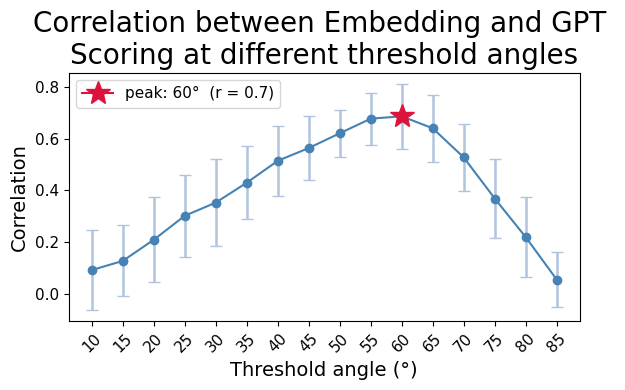

In [32]:
## get the average and std of the correlation across narratives.
correlation_mean = np.nanmean(correlation_scoring, axis=0)
correlation_std  = np.nanstd(correlation_scoring,  axis=0)

# find the peak
peak_idx   = int(np.nanargmax(correlation_mean))
peak_angle = angles[peak_idx]
peak_val   = correlation_mean[peak_idx]

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(angles, correlation_mean, yerr=correlation_std,
            fmt="o-", color="steelblue",
            ecolor="lightsteelblue", elinewidth=1.8, capsize=4)

# star marker at the peak
ax.plot(peak_angle, peak_val, marker="*", color="crimson",
        markersize=18, zorder=5, label=f"peak: {peak_angle}°  (r = {peak_val:.1f})")

ax.set_title("Correlation between Embedding and GPT \nScoring at different threshold angles", fontsize=20)
ax.set_ylabel("Correlation", fontsize=14)
ax.set_xlabel("Threshold angle (°)", fontsize=14)
ax.tick_params(axis='both', labelsize=11)
plt.xticks(angles, rotation=45)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()